# **Reducer Graph**

In [1]:
from typing import TypedDict, Annotated;
import operator;

class TravelState(TypedDict):
    destination: str;
    suggestions: Annotated[list[str], operator.add]; # Reducer
    final_plan: str;

def hotel_agent(state: TravelState) -> dict:

    return {"suggestions": [f"Stay Near {state["destination"]} Downtown"]};

def food_agent(state: TravelState) -> dict:

    return {"suggestions": [f"Try Coffee In {state["destination"]}"]};

def places_agent(state: TravelState) -> dict:

    return {"suggestions": [f"Visit Famous Places In {state["destination"]}"]};

def planner(state: TravelState) -> dict:

    report = "\n".join(f"• {item}" for item in state["suggestions"]);

    return {"final_plan": report};

In [2]:
from langgraph.graph import StateGraph, START, END;
    
builder = StateGraph(TravelState);

builder.add_node("hotel", hotel_agent);

builder.add_node("food", food_agent);

builder.add_node("places", places_agent);

builder.add_node("planner", planner);

builder.add_edge(START, "hotel"); # Sequential Graph

builder.add_edge("hotel", "food");

builder.add_edge("food", "places");

builder.add_edge("places", "planner");

builder.add_edge("planner", END);

graph = builder.compile();

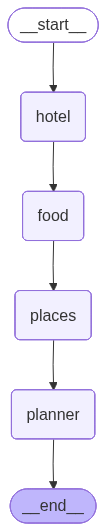

In [3]:
from IPython.display import Image, display;

display(Image(graph.get_graph().draw_mermaid_png()));

In [4]:
result = graph.invoke(
    {
        "destination": "Alkmaar",
        "suggestions": [],
        "final_plan": ""
    }
);

print("Final Result:\n" + result["final_plan"]);

Final Result:
• Stay Near Alkmaar Downtown
• Try Coffee In Alkmaar
• Visit Famous Places In Alkmaar


In [5]:
builder = StateGraph(TravelState);

builder.add_node("hotel", hotel_agent);

builder.add_node("food", food_agent);

builder.add_node("places", places_agent);

builder.add_node("planner", planner);

builder.add_edge(START, "hotel"); # Parallel Graph

builder.add_edge(START, "food");

builder.add_edge(START, "places");

builder.add_edge("hotel", "planner");

builder.add_edge("food", "planner");

builder.add_edge("places", "planner");

builder.add_edge("planner", END);

graph = builder.compile();

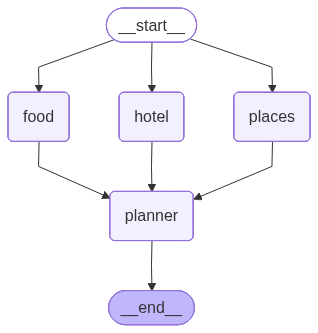

In [6]:
from IPython.display import Image, display;

display(Image(graph.get_graph().draw_mermaid_png()));

In [7]:
result = graph.invoke(
    {
        "destination": "Boras",
        "suggestions": [],
        "final_plan": ""
    }
);

print("Final Result:\n" + result["final_plan"]);

Final Result:
• Try Coffee In Boras
• Stay Near Boras Downtown
• Visit Famous Places In Boras
